In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from landlab import RasterModelGrid, imshow_grid
from landlab.components import OverlandFlowTransporter, FlowAccumulator, TruckPassErosion, DepressionFinderAndRouter
np.set_printoptions(threshold=np.inf)
from erodible_grid import Erodible_Grid

/home/adalvis/github/landlab/src/landlab/utils/matrix.py:5: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import csc_matrix


In [2]:
# Parameters
run_duration = 90  # run duration = days + 1

# call parameters from .csv file
parameters = pd.read_csv("parameters_WY2024.csv")
# site=parameters.loc[parameters["Site Name"] == "KID13"].iloc[0]   # was also doing runs for this site
site=parameters.loc[parameters["Site Name"] == "MEL12"].iloc[0]

# constants
rho_w=1000
rho_s=2650
g=9.81

# grid creation
cell_spacing = 0.1475 # cell width or length dimension in meters
cell_area = cell_spacing**2
nrows = 540 # number of rows in the grid
ncols = 72  # number of columns in the grid

# initialize road layer depths
Sa_ini = 0.01 # active depth in m
Ss_ini = 0.23 # surfacing depth in m
Sb_ini = 2    # ballast depth in m

S = site["Road Gradient"]/100
porosity = 0.35

# initialize average number of truck passes per day for truck pass erosion
truck_num_ini = 4

#We're using half tire width for node spacing
center = 40
half_width = 7 
full_tire = False

ditch_n = 0.05   # manning's roughness of the ditch, based on ditch BMP
ditch_grain_n = 0.05 # manning's roughness for the grains in the ditch
n_c = 0.05   
n_f = 0.015

# fractions of fine and coarse grains in the active layer
# initially 50/50
f_af = 0.5
f_ac = 0.5

# d50 = site["d50 (mm)"]/1000

d50_arr = [0.000018,0.00005,0.0001,0.0002,0.0003,0.0004,0.0005,\
    0.0006,0.0007,0.0008,0.0009,0.001,0.002,0.003,0.004,0.005]
tauc_arr = [0.052,0.101,0.146,0.178,0.199,0.227,0.259,0.291,0.363,\
    0.453,0.524,2.88,1.457,2.185,2.914,3.642]

# index the desired d50 and tau_c values, or find d50 for the site and find tau_c from chart and input here
index_road = 2
index_ditch = 11
d50_road = d50_arr[index_road] # [m] 
d50_ditch = d50_arr[index_ditch]
tau_c_road = tauc_arr[index_road]
tau_c_ditch = tauc_arr[index_ditch]

In [3]:
# Data load and rainfall site selection

# to call high intensity
high_intensity_index = 144  # day index determined to be the beginning of a high intensity rainfall period for this site. 

# intensity data in mm/hr with dt from the dt document
intensity_2024 = pd.read_csv("WY2024_RG_daily_intensity.csv")
# change the site name and index values to get different sites and dates
# intensity_90 = intensity_2024["RG_KID1316_mm"].iloc[:90].values  # first 90 days for site "RG_BISH05"
intensity_90 = intensity_2024["RG_MEL14_mm"].iloc[high_intensity_index:].values 

# daily dt in hours
dt_2024_hours = pd.read_csv("WY2024_RG_daily_dt.csv")
# dt_2024_hours_90 = dt_2024_hours["RG_KID1316_mm"].iloc[:90].values # first 90 days for site "RG_BISH05"
dt_2024_hours_90 = dt_2024_hours["RG_MEL14_mm"].iloc[high_intensity_index:].values  
# convert to dt to days
dt_2024 = np.array(dt_2024_hours_90)/24

In [4]:
eg = Erodible_Grid(nrows=nrows, ncols=ncols,\
    spacing=cell_spacing, full_tire=full_tire, long_slope=S) # update long slope to change DEM

mg, z, road_flag, n = eg() 

noise_amplitude=0.005   # init = 0.005
road = road_flag==1

seed = 1        # this isn't used to calculate rainfall, it ensures that anything else randomly generated isn't 
                # going to be changing between runs. I changed TPE to not have a randomly generated
                # truck number in that file.
np.random.seed(seed)
random=np.random.rand(
    len(z[road])
)
z[road] += noise_amplitude * random #z is the road elevation

#Add depth fields that will update in the component; these are the initial conditions
mg.at_node['active__depth'] = np.ones(nrows*ncols)*Sa_ini #This is the most likely to change; the active layer is essentially 0.005 m right now.
mg.at_node['surfacing__depth'] = np.ones(nrows*ncols)*Ss_ini
mg.at_node['ballast__depth'] = np.ones(nrows*ncols)*Sb_ini #This depth can technically be anything; it just needs to be much larger than the active layer and the surfacing layer depths.

#Add absolute elevation fields that will update based on z updates
mg.at_node['active__elev'] = z
mg.at_node['surfacing__elev'] = z - mg.at_node['active__depth']
mg.at_node['ballast__elev'] = z - mg.at_node['active__depth']\
     - mg.at_node['surfacing__depth']

In [5]:
ruts = [mg.nodes[1:-1, 26:40], mg.nodes[1:-1, 41:55]]
half_road = mg.nodes[1:-1, 9:41]
full_road = mg.nodes[1:-1, 9:72]
ditch = mg.nodes[1:-1, 1:9]

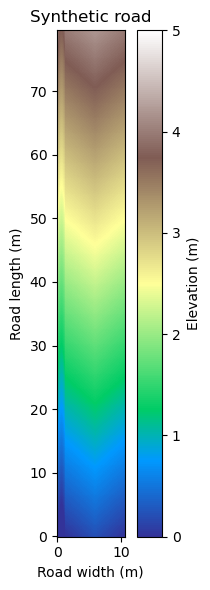

In [6]:
# Set up the figure.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 6))
imshow_grid(mg, z, plot_name='Synthetic road', var_name='Elevation', var_units='m',\
    grid_units=('m', 'm'), cmap='terrain', color_for_closed='black', vmin=0, vmax=5)
plt.xlabel('Road width (m)')
plt.ylabel('Road length (m)')
plt.tight_layout()
plt.show()

In [7]:
tpe = TruckPassErosion(mg, center, half_width, full_tire, truck_num=truck_num_ini, \
    scat_loss=8e-5, f_af=f_af, f_ac=f_ac) #initialize component, 

df_init = DepressionFinderAndRouter(mg, reroute_flow = True)
df_init.map_depressions()

fa = FlowAccumulator(mg, surface='topographic__elevation', \
    flow_director="FlowDirectorD8", runoff_rate=1.538889e-6, \
    depression_finder=None)

oft = OverlandFlowTransporter(mg, porosity=porosity, d50=d50_road, \
    longitudinal_slope=S, tau_c=tau_c_road, n_c=n_c, n_f=n_f)

/home/adalvis/github/landlab/src/landlab/graph/sort/sort.py:724: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  angle_of_spoke_at_hub = np.arctan2(dy, dx, where=spokes_at_hub != -1)


In [8]:
# prep fields

mask = road_flag
z_limit = mg.at_node['topographic__elevation'] - mg.at_node['active__depth'] #You may need to use this to create a layer limit
intensity_arr=[]
dt_arr = []
dz_arr=[]
dz_arr_cum = []

sa_arr=[]
ss_arr=[]
sb_arr=[]

# mask to exclude rut values from full road
mask1 = np.ones(mg.number_of_nodes, dtype=bool)
mask1[ruts] = False

# depth averages for each layer in the ruts
active_fines_ruts = []
surfacing_depth_ruts = []
ballast_depth_ruts = []

# outflux and discharge arrays
mass_ditch_outflow = np.zeros(run_duration)
mass_ditch_inflow = np.zeros(run_duration)
mass_rut_outflow = np.zeros(run_duration)
road_mass_change_oft = np.zeros(run_duration)
ditch_mass_change = np.zeros(run_duration)
channel_discharge_arr = []

road_shear_frac_arr = np.zeros(run_duration)
road_shear = []

# shear stresses (averages)
avg_shear_stress_ruts = []
avg_shear_stress_channel = []
avg_shear_stress_road = []

# manning's roughness averages
avg_n_ruts = []
avg_n_road = []

# sediment load in the ruts due to TPE
tpe_load_ruts = []
tpe_load_ruts_cum = []

# shear stress partitioning coefficient averages
fs_avg_ruts = []
fs_avg_road = []

# look at sediment rate of change for road vs ruts
dzdt_avg_ruts = []
dzdt_avg_road = []

truck_num=0     
z_ini_cum = mg.at_node['topographic__elevation'].copy()


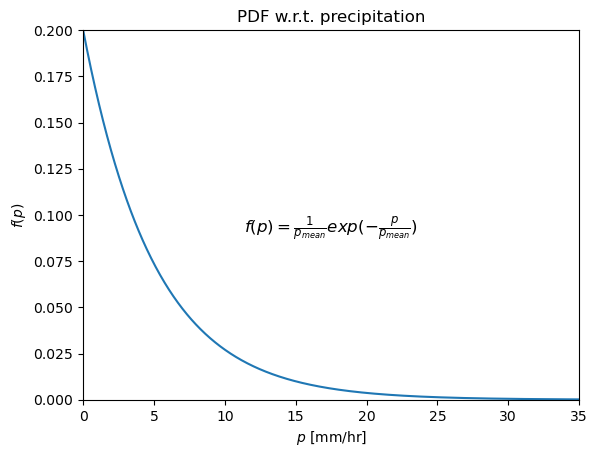

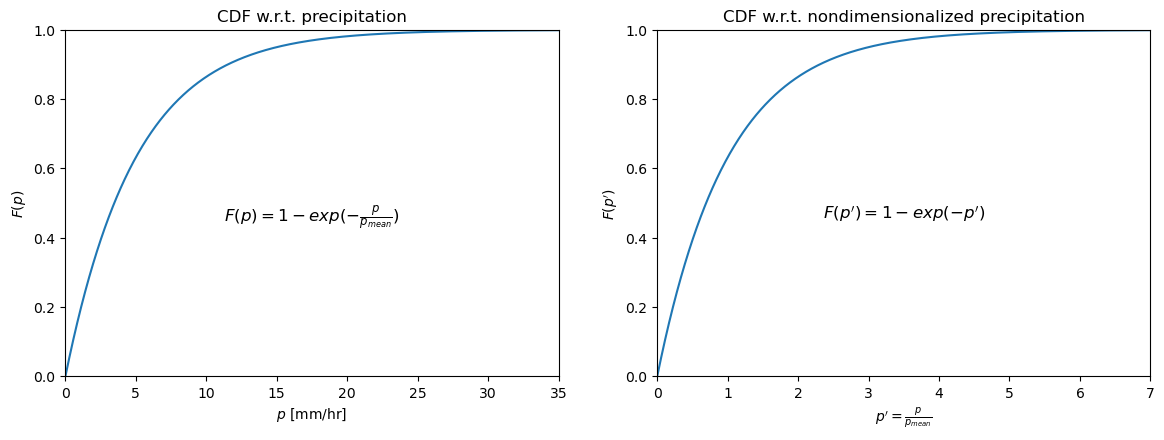

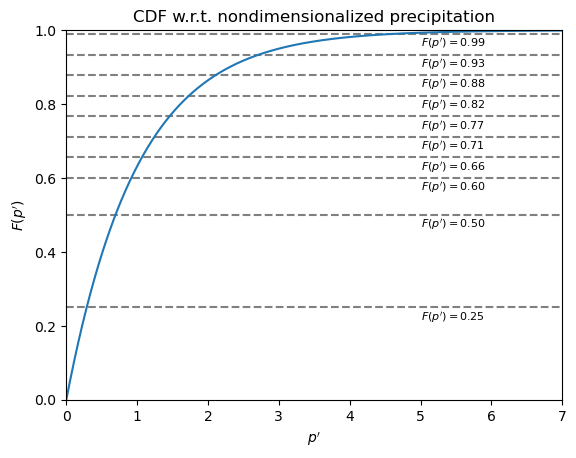

In [9]:
# Intensity distribution per storm
p = np.linspace(0.0001, 35, 1000)
def pdf(p, p_mean):
    p_prime = p/p_mean
    pdf = 1/p_mean*np.exp(-p/p_mean)
    return pdf, p_prime

def cdf(p, p_mean):
    p_prime = p/p_mean
    cdf = 1-np.exp(-p_prime)
    return cdf, p_prime

def p_prime_arr(prob):
    p_prime_arr = -np.log(1-prob)
    return p_prime_arr

prob_arr = np.concatenate((np.array([0.25, 0.5]), np.linspace(0.6, 0.99, 8)))
frac_arr = np.abs(np.concatenate((np.array([0.25]), np.diff(1-prob_arr))))

pdf, p_prime = pdf(p, 5)
cdf, p_prime = cdf(p, 5)
p_prime_arr = p_prime_arr(prob_arr)


fig, ax = plt.subplots()
ax.plot(p, pdf)
ax.annotate(r'$f(p)=\frac{1}{p_{mean}}exp(-\frac{p}{p_{mean}})$', xy=(10,0.1), xycoords='data',
            xytext=(0.5, 0.5), textcoords='axes fraction',
            va='top', ha='center',size=12)
ax.set_xlim(0,35)
ax.set_ylim(0,0.2)
ax.set_xlabel('$p$ [mm/hr]')
ax.set_ylabel('$f(p)$')
ax.set_title('PDF w.r.t. precipitation')
plt.show()

fig, ax = plt.subplots(1,2, figsize=(14,4.5))
ax[0].plot(p, cdf)
ax[0].annotate(r'$F(p)=1-exp{(-\frac{p}{p_{mean}})}$', xy=(10,0.5), xycoords='data',
               xytext=(0.5, 0.5), textcoords='axes fraction',
               va='top', ha='center',size=12)
ax[0].set_xlim(0,35)
ax[0].set_ylim(0,1)
ax[0].set_xlabel('$p$ [mm/hr]')
ax[0].set_ylabel('$F(p)$')
ax[0].set_title('CDF w.r.t. precipitation')

ax[1].plot(p_prime, cdf)
ax[1].annotate("$F(p\')=1-exp{(-p\')}$", xy=(2,0.5), xycoords='data',
               xytext=(0.5, 0.5), textcoords='axes fraction',
               va='top', ha='center',size=12)
ax[1].set_xlim(0,7)
ax[1].set_ylim(0,1)
ax[1].set_xlabel('$p\' =\\frac{p}{p_{mean}}$')
ax[1].set_ylabel('$F(p\')$')
ax[1].set_title('CDF w.r.t. nondimensionalized precipitation')
plt.show()

fig, ax = plt.subplots()
for i in range(len(prob_arr)):
    plt.plot([0, max(p_prime)],[prob_arr[i],prob_arr[i]], '--', color='gray')
ax.plot(p_prime, cdf)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[0], xy=(5, prob_arr[0]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[1], xy=(5, prob_arr[1]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[2], xy=(5, prob_arr[2]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[3], xy=(5, prob_arr[3]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[4], xy=(5, prob_arr[4]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[5], xy=(5, prob_arr[5]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[6], xy=(5, prob_arr[6]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[7], xy=(5, prob_arr[7]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[8], xy=(5, prob_arr[8]-0.035), size=8)
ax.annotate('$F(p\')=%0.2f$'%prob_arr[9], xy=(5, prob_arr[9]-0.035), size=8)
ax.set_xlim(0,7)
ax.set_ylim(0,1)
ax.set_xlabel('$p\'$')
ax.set_ylabel('$F(p\')$')
ax.set_title('CDF w.r.t. nondimensionalized precipitation')
plt.show()

In [10]:
# Main loop

start = time.time()
for i in range(0, run_duration): # daily time step, every time step there are a certain number of truck passes = truck_num
    active_init = mg.at_node['active__depth'].copy()
    surfacing_init = mg.at_node['surfacing__depth'].copy()
    ballast_init = mg.at_node['ballast__depth'].copy()
    z_ini = mg.at_node['topographic__elevation'].copy()

    tpe.run_one_step()

    truck_num += tpe._truck_num
    # Try adding extra perturbation of road surface per truck pass? Before every storm?
    
    intensity = intensity_90[i]  # use the i-th day's intensity
    dt_day = dt_2024[i] # use the i-th day's time step

    if intensity <= 0:
        rain_m_per_s = intensity * 2.77778e-7 # conversion to m/s
        mg.at_node['water__unit_flux_in'] = np.ones(mg.number_of_nodes) * rain_m_per_s
        fa.accumulate_flow()

        intensity_arr.append(0)
        dt_arr.append(0)

        dz = z - z_ini
        dz_arr.append(sum(dz[mask]))

        dz_cum = z - z_ini_cum
        dz_arr_cum.append(sum(dz_cum[mask]))

        # append flux vectors
        mass_rut_outflow[i] = 0
        mass_ditch_outflow[i] = 0
        mass_ditch_inflow[i] = 0
        
        road_shear_frac_arr[i] = 0
        # road_shear.append(np.zeros(nrows*ncols))

        # # append shear stress vectors
        avg_shear_stress_ruts.append(0)
        avg_shear_stress_channel.append(0)
        avg_shear_stress_road.append(0)

        # append manning's roughness vectors
        avg_n_ruts.append(np.nanmean(mg.at_node['total__roughness'][ruts]))
        avg_n_road.append(np.nanmean(mg.at_node['total__roughness'][full_road]))

        # appedn shear stress partitioning coefficient
        fs_avg_ruts.append(np.nanmean(mg.at_node['shear_stress__partitioning'][ruts]))
        fs_avg_road.append(np.nanmean(mg.at_node['shear_stress__partitioning'][full_road]))

        # append sediment rate of change
        dzdt_avg_ruts.append(np.nanmean(mg.at_node['sediment__rate_of_change'][ruts]))
        dzdt_avg_road.append(np.nanmean(mg.at_node['sediment__rate_of_change'][mask1]))

        # append tpe loading
            # multiply change in layer thickness in the ruts by cell area*sediment density*1-porosity
        tpe_load_ruts.append((np.multiply(tpe._active_dz[ruts], cell_area*rho_s*(1-porosity))).sum()) # gives increase in mass in the active layer due to truck passes per time step
        
        # for plotting layer depths
        active_fines = np.average(mg.at_node['active__fines'][ruts])
        active_fines_ruts.append(active_fines)
        surfacing_depth = np.average(mg.at_node['surfacing__depth'][ruts])
        surfacing_depth_ruts.append(surfacing_depth)
        ballast_depth = np.average(mg.at_node['ballast__depth'][ruts])
        ballast_depth_ruts.append(ballast_depth)

    else:
        intensity_arr.append(intensity)
        print(f"Day {i}: Average Intensity = {intensity:.2f} mm/hr")
        dt = dt_day
        dt_arr.append(dt)
        print(f"Day {i}: Length of Storm = {dt:.2f} day")

        for j, storm_frac in enumerate(frac_arr):
            intensity_dist = p_prime_arr[j]*intensity
            print(f"Intensity Distribution = {intensity_dist:.2f} mm/hr")
            dt_frac = storm_frac*dt 
            print(f"Fraction of Storm = {dt_frac:.3f} day")
            #=================================Calculate overland flow transport=================================
            rain_m_per_s = intensity_dist * 2.77778e-7 # conversion to m/s
            mg.at_node['water__unit_flux_in'] = np.ones(mg.number_of_nodes) * rain_m_per_s
            fa.accumulate_flow()
            oft.run_one_step(dt_frac)

            mass_rut_outflow_i = (mg.at_node["sediment__volume_influx"][mg.nodes[1,9:41]]).sum()*rho_s*dt_frac*86400
            mass_ditch_inflow_i = (mg.at_node["sediment__volume_influx"][mg.nodes[1:-1,8]]).sum()*rho_s*dt_frac*86400
            print("Ditch Inflow, Time Step:", mass_ditch_inflow_i)

            mass_rut_outflow[i] += mass_rut_outflow_i
            mass_ditch_inflow[i] += mass_ditch_inflow_i

            road_mass_change_oft[i] = mass_ditch_inflow[i] + mass_rut_outflow[i]

            #=================================Calculate lumped channelized flow transport=================================
            surface_water_discharge = mg.at_node['surface_water__discharge']
            channel_discharge = surface_water_discharge[ditch].sum(axis=1).max()
            channel_discharge_arr.append(channel_discharge)
            
            fs_ditch = (ditch_grain_n/ditch_n)**(24/13)
            a = 0.718
            
            R = ((ditch_n*channel_discharge)**(6/13))/((6*S/a)**(3/13))
            print("R:", R)
            
            # calculates effective shear stress
            ditch_shear_stress = rho_w*g*R*S*fs_ditch

            if ditch_shear_stress > tau_c_ditch:
                sediment_outflux = (
                    ((10**(-4.348)) \
                    / (rho_s*(d50_ditch**0.811))) \
                    * (ditch_shear_stress-tau_c_ditch)**(2.457)) \
                    * np.sqrt((6/a)*R) #[m^3/s]
            else:
                sediment_outflux = 0
            
            print("Ditch Shear Stress:", ditch_shear_stress)

            mass_ditch_outflow_i = sediment_outflux*rho_s*dt_frac*86400*(1-porosity)
            print("Ditch Outflow, Time Step:",mass_ditch_outflow_i)

            mass_ditch_outflow[i] += mass_ditch_outflow_i
            print("Ditch Outflow, Cumulative:",mass_ditch_outflow[i])
        
        
            mg.at_node['shear_stress'] = oft._shear_stress
            road_shear_i = mg.at_node['shear_stress'][full_road]
            # road_shear.append(road_shear_i.flatten())
            road_shear_frac = np.size(road_shear_i[road_shear_i>=tau_c_road])/np.size(road_shear_i)
            road_shear_frac_arr[i] += road_shear_frac*storm_frac

        mg.at_node['shear_stress'] = oft._shear_stress
        avg_shear_stress_ruts.append(np.nanmean(mg.at_node['shear_stress'][ruts]))
        avg_shear_stress_road.append(np.nanmean(mg.at_node['shear_stress'][full_road]))
        avg_shear_stress_channel.append(ditch_shear_stress)
            
        ditch_mass_change[i] = mass_ditch_inflow[i] - mass_ditch_outflow[i]
        
        dz = z-z_ini # calculate elevation change at each daily time step
        dz_arr.append(sum(dz[mask]))

        dz_cum = z-z_ini_cum # calculate cumulative elevation change
        dz_arr_cum.append(sum(dz_cum[mask])) 

        # for plotting layer depths
        active_fines = np.average(mg.at_node['active__fines'][ruts])
        active_fines_ruts.append(active_fines)
        surfacing_depth = np.average(mg.at_node['surfacing__depth'][ruts])
        surfacing_depth_ruts.append(surfacing_depth)
        ballast_depth = np.average(mg.at_node['ballast__depth'][ruts])
        ballast_depth_ruts.append(ballast_depth)
        
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 6))
        im = imshow_grid(mg,'water__depth', var_name='Depth', 
                     plot_name='Water depth, t = %i days' %i,
                     var_units='$m$', grid_units=('m','m'), 
                     cmap='Blues', vmin=0, vmax=0.001, shrink=0.9)
        plt.xlabel('Road width (m)')
        plt.ylabel('Road length (m)')
        plt.tight_layout()
        plt.savefig('output/w_%i_days.png' %i)
        plt.close()
        # plt.show()

        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 6))
        im = imshow_grid(mg,'surface_water__discharge', var_name='Discharge', 
                     plot_name='Discharge, t = %i days' %i,
                     var_units='$m/s^3$', grid_units=('m','m'), 
                     cmap='Blues', vmin=0, vmax=0.00001, shrink=0.9)
        plt.xlabel('Road width (m)')
        plt.ylabel('Road length (m)')
        plt.tight_layout()
        plt.savefig('output/Q_%i_days.png' %i)
        plt.close()
        # plt.show()

        mg.add_field('dz_cum', dz_cum, at='node', units='m', clobber=True)
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 6))
        plt.xlabel('Road width (m)')
        plt.ylabel('Road length (m)')
        im = imshow_grid(mg,'dz_cum', var_name='Cumulative dz', var_units='m', 
                     plot_name='Elevation change, t = %i days' %i,
                     grid_units=('m','m'), cmap='RdBu', vmin=-0.0009, 
                     vmax=0.0009, shrink=0.9)
        plt.xlabel('Road width (m)')
        plt.ylabel('Road length (m)')
        plt.tight_layout()
        plt.savefig('output/dz_cum_%i_days.png' %i)
        plt.close()
        # plt.show()

        # append manning's n vectors
        avg_n_ruts.append(np.nanmean(mg.at_node['total__roughness'][ruts]))
        avg_n_road.append(np.nanmean(mg.at_node['total__roughness'][full_road]))

        # append shear stress partitioning coefficient vectors        
        fs_avg_ruts.append(np.nanmean(mg.at_node['shear_stress__partitioning'][ruts]))
        fs_avg_road.append(np.nanmean(mg.at_node['shear_stress__partitioning'][full_road]))
        
        # append tpe loading
        tpe_load_ruts.append((np.multiply(tpe._active_dz[ruts], cell_area*rho_s*(1-porosity))).sum())
        
        # append sediment rate of change
        dzdt_avg_ruts.append(np.nanmean(mg.at_node['sediment__rate_of_change'][ruts]))
        dzdt_avg_road.append(np.nanmean(mg.at_node['sediment__rate_of_change'][mask1]))
    # cumulative tpe load in the ruts over time
    tpe_load_ruts_cum = np.cumsum(tpe_load_ruts)

wall_time = time.time() - start
print("Wall time for run:", wall_time, "s")

Day 0: Average Intensity = 0.37 mm/hr
Day 0: Length of Storm = 0.12 day
Intensity Distribution = 0.11 mm/hr
Fraction of Storm = 0.031 day
Ditch Inflow, Time Step: 0.0
R: 0.0017372764793382536
Ditch Shear Stress: 0.8521341131154134
Ditch Outflow, Time Step: 0.0
Ditch Outflow, Cumulative: 0.0
Intensity Distribution = 0.26 mm/hr
Fraction of Storm = 0.031 day
Ditch Inflow, Time Step: 0.0
R: 0.0026069632854221715
Ditch Shear Stress: 1.2787154914995753
Ditch Outflow, Time Step: 0.0
Ditch Outflow, Cumulative: 0.0
Intensity Distribution = 0.34 mm/hr
Fraction of Storm = 0.012 day
Ditch Inflow, Time Step: 0.0
R: 0.002965355415577958
Ditch Shear Stress: 1.4545068313409886
Ditch Outflow, Time Step: 0.0
Ditch Outflow, Cumulative: 0.0
Intensity Distribution = 0.40 mm/hr
Fraction of Storm = 0.007 day
Ditch Inflow, Time Step: 0.0
R: 0.0031802725850327944
Ditch Shear Stress: 1.5599237029585857
Ditch Outflow, Time Step: 0.0
Ditch Outflow, Cumulative: 0.0
Intensity Distribution = 0.46 mm/hr
Fraction of S

In [11]:
#Calculations for plots
road_mass_change_dz = np.multiply(dz_arr, (cell_area*rho_s*(1-porosity)))/2
cum_road_mass_change_dz = np.multiply(dz_arr_cum, cell_area*rho_s*(1-porosity))/2

cum_road_mass_change_oft = road_mass_change_oft.cumsum()

total_ditch_mass_change = ditch_mass_change

cum_mass_ditch_inflow = mass_ditch_inflow.cumsum()
cum_mass_ditch_outflow = mass_ditch_outflow.cumsum()

In [12]:
from PIL import Image
import glob

path = "output/"
images_w=[]
images_Q=[]
images_dz=[]
for file in glob.glob(path+'w*.png'):
    images_w.append(file)
for file in glob.glob(path+'Q*.png'):
    images_Q.append(file)
for file in glob.glob(path+'dz_cum*.png'):
    images_dz.append(file)

def number(filename):
    return int(filename[9:-9])

def num(filename):
    return int(filename[14:-9])

images_w = sorted(images_w, key=number)
images_Q = sorted(images_Q, key=number)
images_dz= sorted(images_dz, key=num)

# Create a list of image objects
image_list_w = [Image.open(file) for file in images_w]
image_list_Q = [Image.open(file) for file in images_Q]
image_list_dz = [Image.open(file) for file in images_dz]

# Save the first image as a GIF file
image_list_w[0].save(
            'water_depth.gif',
            save_all=True,
            append_images=image_list_w[1:], # append rest of the images
            duration=1000, # in milliseconds
            loop=0)

image_list_Q[0].save(
            'discharge.gif',
            save_all=True,
            append_images=image_list_Q[1:], # append rest of the images
            duration=1000, # in milliseconds
            loop=0)

image_list_dz[0].save(
            'dz_cum.gif',
            save_all=True,
            append_images=image_list_dz[1:], # append rest of the images
            duration=1000, # in milliseconds
            loop=0)

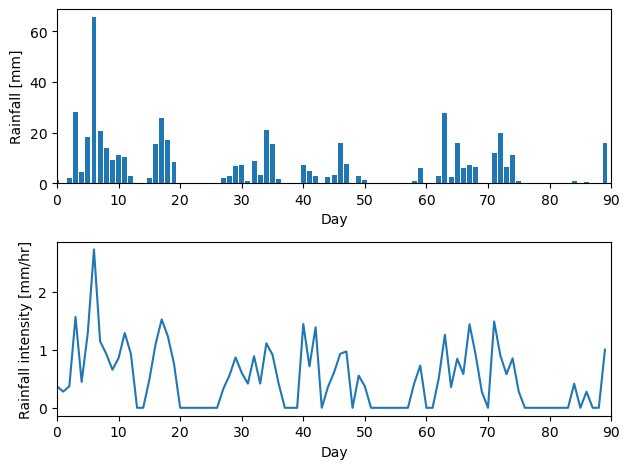

In [13]:
fig, ax = plt.subplots(2,1)
ax[0].bar(range(0,run_duration), np.multiply(intensity_arr,np.multiply(dt_arr,24)))
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Rainfall [mm]')
ax[0].set_xlim(0,run_duration)

ax[1].plot(range(0,run_duration), intensity_arr)
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Rainfall intensity [mm/hr]')
ax[1].set_xlim(0,run_duration)
plt.tight_layout()
plt.show()

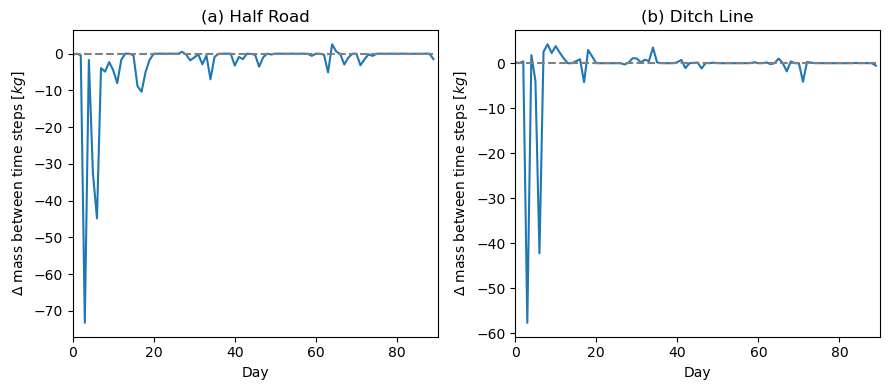

In [14]:
fig, ax = plt.subplots(1,2, figsize=(9,4))

# plot total mass change between time steps on the road
ax[0].plot(range(0,run_duration), -road_mass_change_oft) # added porosity consideration
ax[0].plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
ax[0].set_xlabel('Day')
ax[0].set_ylabel(r'$\Delta$ mass between time steps [$kg$]')
ax[0].set_xlim(0,run_duration)
ax[0].set_title('(a) Half Road')

# plot total mass change between time steps along the ditch line
ax[1].plot(range(0,run_duration), ditch_mass_change)
ax[1].plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
ax[1].set_xlabel('Day')
ax[1].set_ylabel(r'$\Delta$ mass between time steps [$kg$]')
ax[1].set_xlim(0,run_duration)
ax[1].set_title('(b) Ditch Line')
plt.tight_layout()
plt.show()

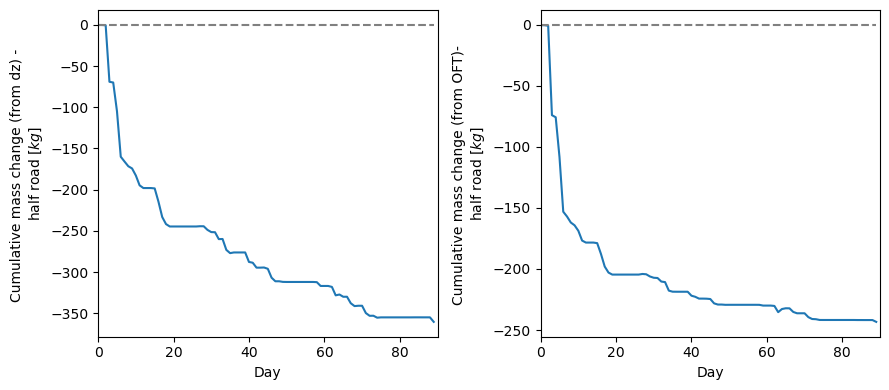

In [15]:
fig, ax = plt.subplots(1,2, figsize=(9,4))

ax[0].plot(range(0,run_duration), cum_road_mass_change_dz) # added porosity consideration
ax[0].plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Cumulative mass change (from dz) - \nhalf road [$kg$]')
ax[0].set_xlim(0,run_duration)

ax[1].plot(range(0,run_duration), -cum_road_mass_change_oft)
ax[1].plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Cumulative mass change (from OFT)- \nhalf road [$kg$]')
ax[1].set_xlim(0,run_duration)
plt.tight_layout()
plt.show()

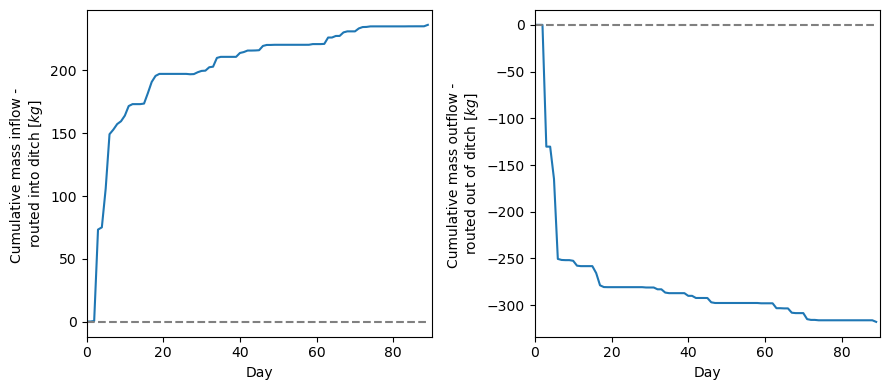

In [16]:
# plot mass inflow into ditch - cumulative and between time steps
fig, ax = plt.subplots(1,2, figsize=(9,4))
ax[0].plot(range(0,run_duration), cum_mass_ditch_inflow)
ax[0].plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
ax[0].set_xlabel('Day')
ax[0].set_ylabel('Cumulative mass inflow - \nrouted into ditch [$kg$]')
ax[0].set_xlim(0,run_duration)

ax[1].plot(range(0,run_duration), -cum_mass_ditch_outflow)
ax[1].plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Cumulative mass outflow - \nrouted out of ditch [$kg$]')
ax[1].set_xlim(0,run_duration)
plt.tight_layout()
plt.show()


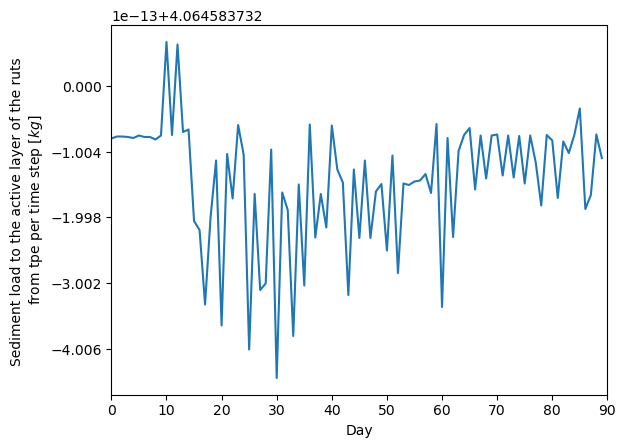

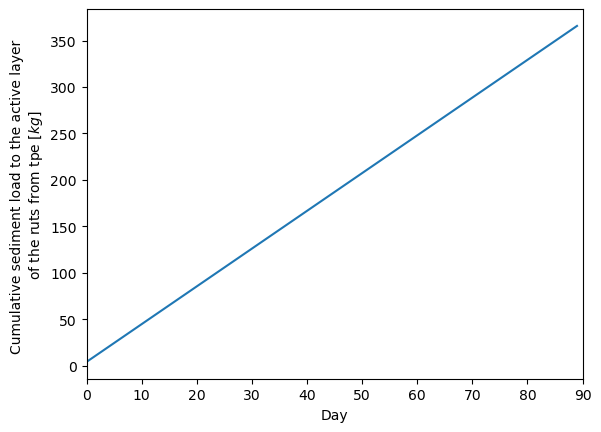

In [17]:
# additional plots

# scattering, pumping, crushing plots
# plot cumulative fluxes
# this plot needs to be looked at!
# q_cs = tpe._q_cs    # [m/truck] crushing
# sum_q_cs = q_cs[mg.nodes[1,9:41]].sum() # summed across the rut for half road
# q_ps = tpe._q_ps    # [m/truck] pumping
# sum_q_ps = q_ps[mg.nodes[1,9:41]].sum() # summed across the rut for half road
# # q are in m/truck not m/s so shouldn't be multiplied by dt_arr, should be multiplied by truck number?
# plt.plot(range(0,run_duration), (np.multiply(sum_q_cs, dt_arr)*rho_s).cumsum(), color='pink', label='crushing')
# plt.plot(range(0,run_duration), (np.multiply(sum_q_ps, dt_arr)*rho_s).cumsum(), color='green', label='pumping')
# plt.plot(range(0,run_duration), np.zeros(len(range(0,run_duration))), '--', color='gray')
# plt.xlabel('Day')
# plt.ylabel('Pumping and Crushing Fluxes [kg]')
# plt.xlim(0,run_duration)
# plt.legend()
# plt.show()

# plot sediment load to the active layer in the ruts from truck passes per time step
    # this will vary when we allow truck number to vary
plt.plot(range(0,run_duration), tpe_load_ruts)
plt.xlabel('Day')
plt.ylabel('Sediment load to the active layer of the ruts \nfrom tpe per time step [$kg$]')
plt.xlim(0,run_duration)
plt.show()

# plot cumulative sediment load to the active layer in the ruts from truck passes over time
    # won't be near linear when truck number is allowed to vary 
plt.plot(range(0,run_duration), tpe_load_ruts_cum)
plt.xlabel('Day')
plt.ylabel('Cumulative sediment load to the active layer \nof the ruts from tpe [$kg$]')
plt.xlim(0,run_duration)
plt.show()


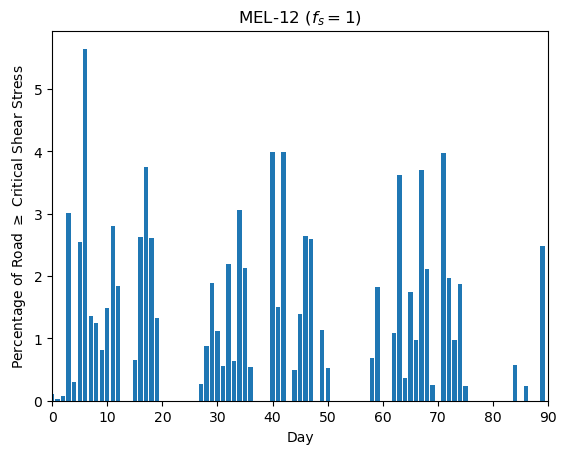

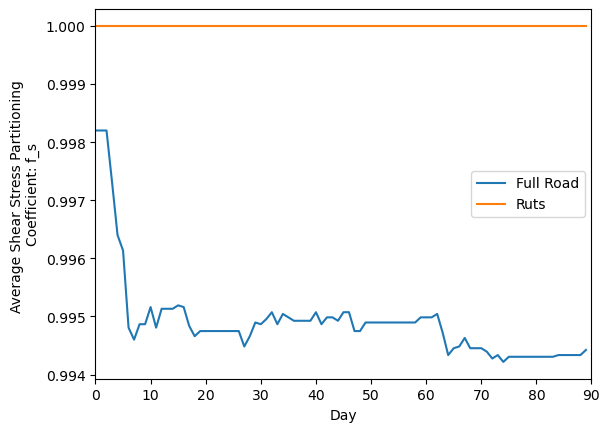

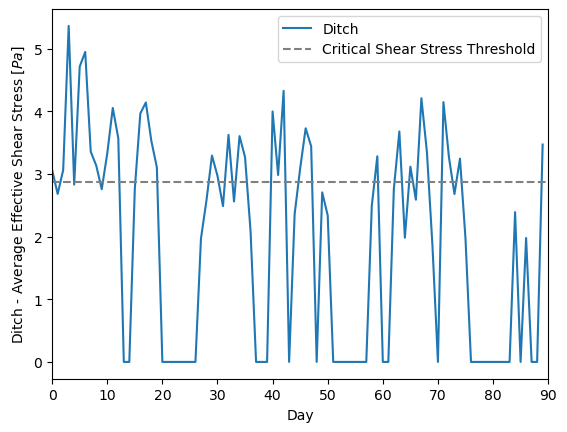

In [18]:
plt.bar(range(0,run_duration), np.multiply(road_shear_frac_arr, 100))
plt.xlabel('Day')
plt.ylabel(r'Percentage of Road $\geq$ Critical Shear Stress')
plt.xlim(0,run_duration)
plt.title(r'MEL-12 ($f_s = 1$)')
plt.show()

# plot shear stress partitioning coefficient over time
plt.plot(range(0,run_duration), fs_avg_road, label='Full Road')
plt.plot(range(0,run_duration), fs_avg_ruts, label='Ruts')
plt.xlabel('Day')
plt.ylabel('Average Shear Stress Partitioning \nCoefficient: f_s')
plt.xlim(0,run_duration)
plt.legend()
plt.show()

# # plot average shear stresses on the road
# # Perhaps do max shear stresses? Is this helpful?
# plt.plot(range(0,run_duration), avg_shear_stress_road, label = 'Full Road')
# plt.plot(range(0,run_duration), avg_shear_stress_ruts, label = 'Ruts')
# plt.axhline(tau_c_road, linestyle='--', color='gray', label='Critical Shear Stress Threshold')
# plt.xlabel('Day')
# plt.ylabel('Road - Average Effective Shear Stress [$Pa$]')
# plt.xlim(0,run_duration)
# plt.legend()
# plt.show()

# plot average shear stress in the ditch
plt.plot(range(0,run_duration), avg_shear_stress_channel, label = 'Ditch')
plt.axhline(tau_c_ditch, linestyle='--', color='gray', label='Critical Shear Stress Threshold')
plt.xlabel('Day')
plt.ylabel('Ditch - Average Effective Shear Stress [$Pa$]')
plt.xlim(0,run_duration)
plt.legend()
plt.show()


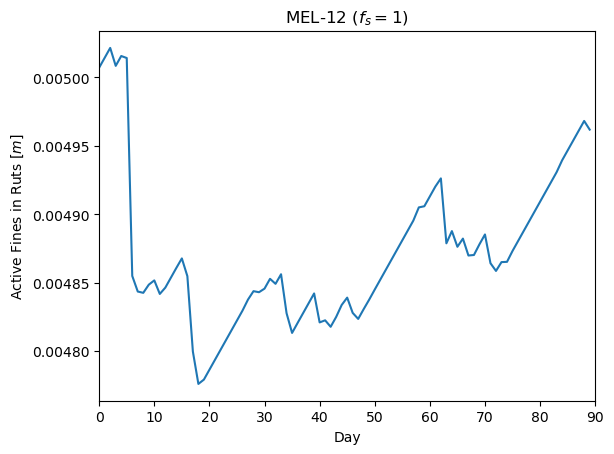

In [19]:
# plot average active layer thickness over time in the ruts
plt.plot(range(0,run_duration), active_fines_ruts)
plt.xlabel('Day')
plt.ylabel('Active Fines in Ruts [$m$]')
plt.xlim(0,run_duration)
plt.title(r'MEL-12 ($f_s = 1$)')
plt.show()

# these have been a bit unnecessary to plot because they are relatively unchanging.
# they lose on the order of 1e-7 m per day of thickness due to TPE processes only.
# if truck_num is varied then these plots will provide more meaning.

# # plot average surfacing layer thickness over time in the ruts
# plt.plot(range(0,run_duration), surfacing_depth_ruts)
# plt.xlabel('Day')
# plt.ylabel('Surfacing Depth in ruts [$m$]')
# plt.xlim(0,run_duration)
# plt.show()

# # plot average ballast layer thickness over time in the ruts
# plt.plot(range(0,run_duration), ballast_depth_ruts)
# plt.xlabel('Day')
# plt.ylabel('Ballast Depth in ruts [$m$]')
# plt.xlim(0,run_duration)
# plt.show()


In [20]:
total_dz = np.abs(min(dz_arr_cum)) 
total_dV = total_dz*cell_area # create area of cell variable and multiply by that instead, use cell_spacing at the top and convert to area
total_load = total_dV*rho_s*(1-porosity)
total_load_div = total_load/2

print(
    "Total rainfall,",run_duration, "days:", sum(np.multiply(intensity_arr,np.multiply(dt_arr,24))), 'mm'
    )

# kind of understand this sediment__added, but why would this be different than what I calculated for the sediment load from TPE
print(
    'Sediment pumped:', mg.at_node['sediment__added'].sum()*cell_area*rho_s*(1-porosity), 'kg'
    )
    
print(
    'Cumulative sediment load from road (half-road dz estimate):', total_load_div, 'kg'
    )

print(
    'Cumulative sediment load from road (half-road OFT calculation):', (mass_ditch_inflow + mass_rut_outflow).sum(), 'kg' 
    )

print('Comparison between sediment load from road elevation change calculation and channel influx from OFT:',\
    total_load_div - (mass_ditch_inflow + mass_rut_outflow).sum()
    )

print(
    'Cumulative sediment flux from road & ditch:', (mass_ditch_outflow + mass_rut_outflow).sum(), 'kg'
    )

Total rainfall, 90 days: 518.021533995 mm
Sediment pumped: 367.17243381000105 kg
Cumulative sediment load from road (half-road dz estimate): 360.3697591315094 kg
Cumulative sediment load from road (half-road OFT calculation): 243.32640930713075 kg
Comparison between sediment load from road elevation change calculation and channel influx from OFT: 117.04334982437865
Cumulative sediment flux from road & ditch: 325.1134417789063 kg
